--- OVERFITTING MODELİ (Sərhədsiz) ---
Train Dəqiqliyi: 100.00% (Model datanı əzbərlədi)
Test Dəqiqliyi:  85.33% (Yeni datada zəif nəticə)

--- REGULARIZED MODEL (Tənzimlənmiş) ---
Train Dəqiqliyi: 90.29% (Əzbərləməyə icazə verilmədi)
Test Dəqiqliyi:  88.67% (Daha yaxşı ümumiləşdirmə)


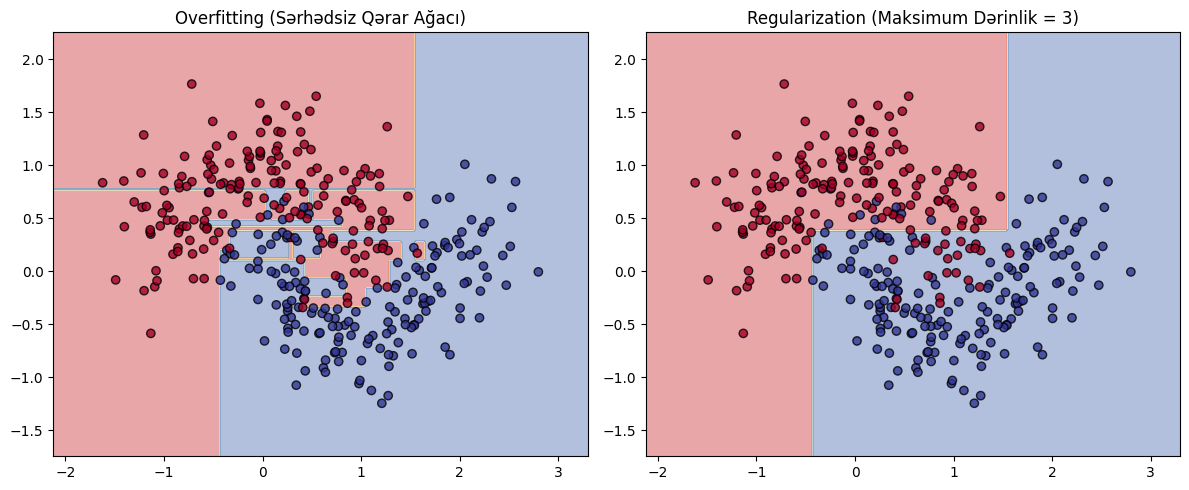

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score


X, y = make_moons(n_samples=500, noise=0.3, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


overfit_model = DecisionTreeClassifier(max_depth=None, random_state=42)
overfit_model.fit(X_train, y_train)

train_acc_overfit = accuracy_score(y_train, overfit_model.predict(X_train))
test_acc_overfit = accuracy_score(y_test, overfit_model.predict(X_test))

print("--- OVERFITTING MODELİ (Sərhədsiz) ---")
print(f"Train Dəqiqliyi: {train_acc_overfit * 100:.2f}% (Model datanı əzbərlədi)")
print(f"Test Dəqiqliyi:  {test_acc_overfit * 100:.2f}% (Yeni datada zəif nəticə)\n")


reg_model = DecisionTreeClassifier(max_depth=3, random_state=42)
reg_model.fit(X_train, y_train)

train_acc_reg = accuracy_score(y_train, reg_model.predict(X_train))
test_acc_reg = accuracy_score(y_test, reg_model.predict(X_test))

print("--- REGULARIZED MODEL (Tənzimlənmiş) ---")
print(f"Train Dəqiqliyi: {train_acc_reg * 100:.2f}% (Əzbərləməyə icazə verilmədi)")
print(f"Test Dəqiqliyi:  {test_acc_reg * 100:.2f}% (Daha yaxşı ümumiləşdirmə)")


def plot_decision_boundary(model, X, y, title, ax):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.RdYlBu)
    ax.scatter(X[:, 0], X[:, 1], c=y, alpha=0.8, edgecolor='k', cmap=plt.cm.RdYlBu)
    ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_decision_boundary(overfit_model, X_train, y_train, "Overfitting (Sərhədsiz Qərar Ağacı)", axes[0])
plot_decision_boundary(reg_model, X_train, y_train, "Regularization (Maksimum Dərinlik = 3)", axes[1])
plt.tight_layout()
plt.show()

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim

class SimpleAIModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer = nn.Linear(10, 2) 

    def forward(self, x):
        return self.layer(x)

model = SimpleAIModel()


criterion = nn.CrossEntropyLoss() 


optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

def train_step(batch_x, batch_y):
    model.train() 
    
    optimizer.zero_grad() 
    
    predictions = model(batch_x) 
    loss = criterion(predictions, batch_y) 
    
    loss.backward() 
    optimizer.step() 
    
    return loss.item()



data_x = torch.randn(100, 10)
data_y = torch.randint(0, 2, (100,))

print("Məşq başlayır...\n")

for epoch in range(1, 11):
    current_loss = train_step(data_x, data_y)
    
    if epoch % 2 == 0: # Hər 2 addımdan bir nəticəni çap et
        print(f"Dərs (Epoch): {epoch} | Səhv (Loss): {current_loss:.4f}")

print("\nÖyrənmə tamamlandı!")

Məşq başlayır...

Dərs (Epoch): 2 | Səhv (Loss): 0.7680
Dərs (Epoch): 4 | Səhv (Loss): 0.7653
Dərs (Epoch): 6 | Səhv (Loss): 0.7625
Dərs (Epoch): 8 | Səhv (Loss): 0.7599
Dərs (Epoch): 10 | Səhv (Loss): 0.7572

Öyrənmə tamamlandı!


In [13]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 1. Süni data yaradırıq: 1000 nəfər, 20 fərqli xüsusiyyət
X, y = make_classification(n_samples=1000, n_features=20, random_state=42)

# 2. Datanı bölürük: 90% öyrənmək (Train), 10% imtahan (Test) üçün
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# max_depth=None: Robota deyirik ki, nə qədər istəyirsən dərinə get, hər xırdalığı əzbərlə
model_ezberci = DecisionTreeClassifier(max_depth=None, random_state=42)
model_ezberci.fit(X_train, y_train)

# Nəticələri yoxlayırıq
train_acc = accuracy_score(y_train, model_ezberci.predict(X_train))
test_acc = accuracy_score(y_test, model_ezberci.predict(X_test))

print(f"Əzbərçi Model - Train: {train_acc*100}%, Test: {test_acc*100}%")
# max_depth=5: Robota deyirik ki, ancaq ən vacib 5 suala bax, detallara girmə
model_mentiqli = DecisionTreeClassifier(max_depth=5, random_state=42)
model_mentiqli.fit(X_train, y_train)

# Nəticələri yoxlayırıq
train_acc_reg = accuracy_score(y_train, model_mentiqli.predict(X_train))
test_acc_reg = accuracy_score(y_test, model_mentiqli.predict(X_test))

print(f"Məntiqli Model - Train: {train_acc_reg*100:.2f}%, Test: {test_acc_reg*100:.2f}%")

Əzbərçi Model - Train: 100.0%, Test: 87.0%
Məntiqli Model - Train: 94.67%, Test: 88.00%


In [27]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sympy.codegen.ast import none

X,y = make_classification(n_samples=1000,n_features=20,random_state=42)

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.1,random_state=42)

ezberci_model=DecisionTreeClassifier(max_depth=None,random_state=42)
ezberci_model.fit(X_train,y_train)

train_accuracy=accuracy_score(y_train,ezberci_model.predict(X_train))
test_accuracy=accuracy_score(y_test,ezberci_model.predict(X_test))



mentiqli_model=DecisionTreeClassifier(max_depth=5,random_state=42)
mentiqli_model.fit(X_train,y_train)

train_accuracy_mentiqli=accuracy_score(y_train,mentiqli_model.predict(X_train))
test_accuracy_mentiqli=accuracy_score(y_test,mentiqli_model.predict(X_test))

# Print hissəsini hesabladığın dəyişən adlarına uyğunlaşdır:
print(f"Əzbərçi Model - Train: {train_accuracy*100:.2f}%, Test: {test_accuracy*100:.2f}%")
print(f"Məntiqli Model - Train: {train_accuracy_mentiqli*100:.2f}%, Test: {test_accuracy_mentiqli*100:.2f}%")

Əzbərçi Model - Train: 100.00%, Test: 87.00%
Məntiqli Model - Train: 100.00%, Test: 87.00%


In [29]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sympy.codegen.ast import none


X, y = make_classification(n_samples= 1000,n_features=20,random_state=42)
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

for depth in range(1,16):
    
    model = DecisionTreeClassifier(max_depth=depth)
    
    model.fit(X_train,y_train)
    
    train_accuracy=accuracy_score(y_train,model.predict(X_train))
    test_accuracy=accuracy_score(y_test,model.predict(X_test))
    
    print('Depth: ',depth,'Train Accuracy: ',train_accuracy,'Test Accuracy: ',test_accuracy)

Depth:  1 Train Accuracy:  0.87625 Test Accuracy:  0.86
Depth:  2 Train Accuracy:  0.88 Test Accuracy:  0.865
Depth:  3 Train Accuracy:  0.88625 Test Accuracy:  0.865
Depth:  4 Train Accuracy:  0.93125 Test Accuracy:  0.88
Depth:  5 Train Accuracy:  0.93875 Test Accuracy:  0.875
Depth:  6 Train Accuracy:  0.96625 Test Accuracy:  0.875
Depth:  7 Train Accuracy:  0.98125 Test Accuracy:  0.86
Depth:  8 Train Accuracy:  0.98375 Test Accuracy:  0.865
Depth:  9 Train Accuracy:  0.99125 Test Accuracy:  0.87
Depth:  10 Train Accuracy:  0.9975 Test Accuracy:  0.855
Depth:  11 Train Accuracy:  0.99875 Test Accuracy:  0.87
Depth:  12 Train Accuracy:  1.0 Test Accuracy:  0.855
Depth:  13 Train Accuracy:  1.0 Test Accuracy:  0.85
Depth:  14 Train Accuracy:  1.0 Test Accuracy:  0.84
Depth:  15 Train Accuracy:  1.0 Test Accuracy:  0.86


In [33]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score


X,y=make_classification(n_samples=1000,n_features=20,random_state=42)

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)


ezberci_model=DecisionTreeClassifier(max_depth=None,random_state=42)
ezberci_model.fit(X_train,y_train)

train_accuracy_ezberci=accuracy_score(y_train,ezberci_model.predict(X_train))
test_accuracy_ezberci=accuracy_score(y_test,ezberci_model.predict(X_test))

mentiqli_model=DecisionTreeClassifier(max_depth=4,random_state=42)
mentiqli_model.fit(X_train,y_train)

train_accuracy_mentiqli=accuracy_score(y_train,mentiqli_model.predict(X_train))
test_accuracy_mentiqli=accuracy_score(y_test,mentiqli_model.predict(X_test))

print(train_accuracy_ezberci)
print(train_accuracy_mentiqli)
print(test_accuracy_ezberci)
print(test_accuracy_mentiqli)

1.0
0.9328571428571428
0.8566666666666667
0.8666666666666667
